In [ ]:
# # Part 3: NLP and Sequence Modeling Mini Project

# In this notebook, I am working on a customer support text classification task.
# The goal is to classify customer messages into positive, neutral, or negative sentiment.

# I will first build a simple baseline model using TF-IDF, and then compare it with
# a sequence-based deep learning model using an LSTM.


In [19]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import nltk
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# download stopwords once
nltk.download("stopwords")

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# create results folder
os.makedirs("results", exist_ok=True)

sns.set_style("whitegrid")

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# ## Task 1: Dataset Understanding
# First I will load the dataset and explore the text column, class labels, average
# text length, and class distribution.


In [18]:
df = pd.read_csv("/content/customer_support_text_classification.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [20]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget classes:")
print(df["sentiment_label"].value_counts())


Columns:
['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target classes:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [21]:
print("Sample customer messages:\n")
for i, msg in enumerate(df["customer_message"].head(5), start=1):
    print(f"{i}. {msg}\n")


Sample customer messages:

1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

2. I need information about the payment process.

3. The refund process was fast and convenient. I appreciate the quick response.

4. My refund is still pending and this experience is frustrating. My ticket number is 33927.

5. Please tell me how to update my account details.



In [22]:
# average text length in words
df["text_len"] = df["customer_message"].astype(str).apply(lambda x: len(x.split()))

print("Average text length:", round(df["text_len"].mean(), 2))
print("Minimum text length:", df["text_len"].min())
print("Maximum text length:", df["text_len"].max())


Average text length: 12.72
Minimum text length: 7
Maximum text length: 26


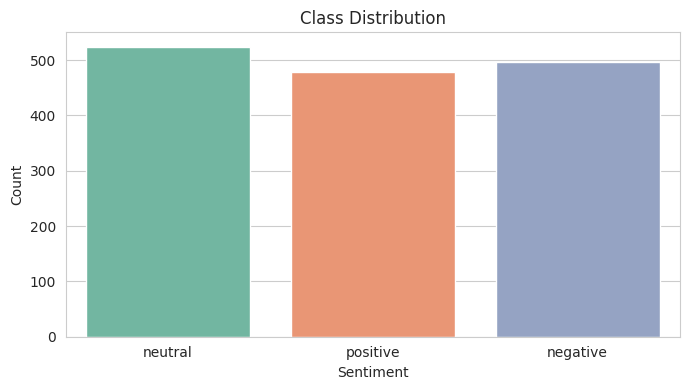

In [23]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="sentiment_label", palette="Set2")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
# ### Observation
# This is a multi-class text classification dataset with three classes:
# positive, neutral, and negative.

# The main input column is `customer_message`, and the label column is `sentiment_label`.


In [ ]:
# ## Task 2: Text Preprocessing
# I will clean the text by:
# - lowercasing
# - removing special characters and digits
# - removing extra spaces

# For the baseline model, I will also remove stopwords.
# For the sequence model, I will tokenize and pad the text.


In [24]:
stop_words = set(stopwords.words("english"))

def clean_text(text, remove_stopwords=False):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()

    if remove_stopwords:
        words = text.split()
        words = [w for w in words if w not in stop_words]
        text = " ".join(words)

    return text


In [25]:
df["clean_text_basic"] = df["customer_message"].apply(lambda x: clean_text(x, remove_stopwords=False))
df["clean_text_tfidf"] = df["customer_message"].apply(lambda x: clean_text(x, remove_stopwords=True))

df[["customer_message", "clean_text_basic", "clean_text_tfidf"]].head()


,customer_message,clean_text_basic,clean_text_tfidf
0,I need information about the payment process. ...,i need information about the payment process m...,need information payment process ticket number...
1,I need information about the payment process.,i need information about the payment process,need information payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,my refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell me how to update my account details,please tell update account details


In [ ]:
# ## Task 3: Text Vectorization

# Text must be converted into vectors because machine learning models work with numbers,
# not raw words.

# Here I am using:
# - **TF-IDF** for the baseline model
# - **Tokenizer + padded sequences** for the sequence model


In [26]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["sentiment_label"])

print("Label mapping:")
for cls, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{cls} -> {idx}")


Label mapping:
negative -> 0
neutral -> 1
positive -> 2


In [27]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text_tfidf"],
    df["label_encoded"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_encoded"]
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))


Train size: 1200
Test size: 300


In [ ]:
# ## Task 4: Baseline Model
# For the baseline, I am using **TF-IDF + Logistic Regression**.
# This is a strong and simple traditional NLP baseline.


In [28]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)


TF-IDF train shape: (1200, 427)
TF-IDF test shape: (300, 427)


In [29]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

y_pred_base = baseline_model.predict(X_test_tfidf)

baseline_acc = accuracy_score(y_test, y_pred_base)
print("Baseline Accuracy:", round(baseline_acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_base, target_names=label_encoder.classes_))


Baseline Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



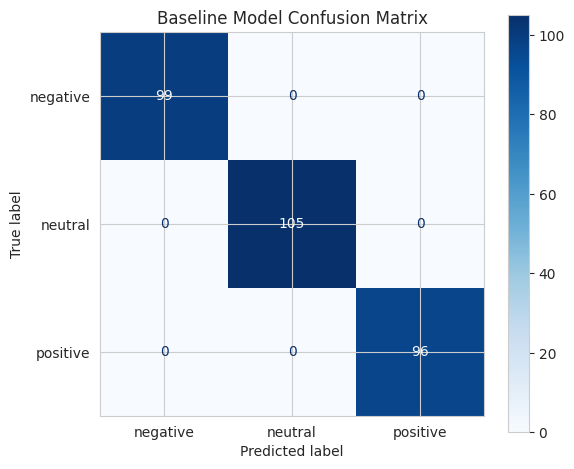

In [30]:
cm = confusion_matrix(y_test, y_pred_base)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", ax=ax)
plt.title("Baseline Model Confusion Matrix")
plt.tight_layout()
plt.show()


In [31]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [round(baseline_acc, 4)]
})

baseline_results.to_csv("results/model_evaluation.csv", index=False)
baseline_results


,Model,Accuracy
0,TF-IDF + Logistic Regression,1.0


In [ ]:
# ## Task 5: Sequence Model
# Now I will build a simple LSTM-based sequence model.

# This model will process the text in this order:
# 1. Input text
# 2. Tokenizer converts words to integer sequences
# 3. Sequences are padded to the same length
# 4. Embedding layer converts word IDs into dense vectors
# 5. LSTM learns the sequence information
# 6. Dense output layer predicts the sentiment class


In [32]:
X_train_seq_text, X_test_seq_text, y_train_seq, y_test_seq = train_test_split(
    df["clean_text_basic"],
    df["label_encoded"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_encoded"]
)


In [33]:
max_words = 5000
max_len = 25

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_seq_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_seq_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_seq_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("Padded train shape:", X_train_pad.shape)
print("Padded test shape:", X_test_pad.shape)


Padded train shape: (1200, 25)
Padded test shape: (300, 25)


In [34]:
num_classes = len(label_encoder.classes_)

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = lstm_model.fit(
    X_train_pad, y_train_seq,
    validation_split=0.2,
    epochs=8,
    batch_size=32,
    verbose=1
)


Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.4302 - loss: 1.0866 - val_accuracy: 0.6375 - val_loss: 0.9869
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6594 - loss: 0.5841 - val_accuracy: 0.7042 - val_loss: 0.4627
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6958 - loss: 0.4548 - val_accuracy: 0.7500 - val_loss: 0.4412
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8490 - loss: 0.3437 - val_accuracy: 1.0000 - val_loss: 0.0916
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9875 - loss: 0.0669 - val_accuracy: 0.9708 - val_loss: 0.1205
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9990 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 8/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss:

In [36]:
test_loss, test_acc = lstm_model.evaluate(X_test_pad, y_test_seq, verbose=0)
print("LSTM Test Accuracy:", round(test_acc, 4))


LSTM Test Accuracy: 1.0


In [37]:
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad, verbose=0), axis=1)

print(classification_report(y_test_seq, y_pred_lstm, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [38]:
# save sample predictions
sample_preds = pd.DataFrame({
    "text": X_test_seq_text.reset_index(drop=True).head(10),
    "actual": label_encoder.inverse_transform(np.array(y_test_seq[:10])),
    "predicted": label_encoder.inverse_transform(y_pred_lstm[:10])
})

with open("results/sample_predictions.txt", "w", encoding="utf-8") as f:
    for i, row in sample_preds.iterrows():
        f.write(f"Sample {i+1}\n")
        f.write(f"Text      : {row['text']}\n")
        f.write(f"Actual    : {row['actual']}\n")
        f.write(f"Predicted : {row['predicted']}\n")
        f.write("-"*60 + "\n")

sample_preds


,text,actual,predicted
0,i like the new payment and it is easy to use m...,positive,positive
1,great service and clear communication from the...,positive,positive
2,my refund is still pending and this experience...,negative,negative
3,the app crashes whenever i try to use analytics,negative,negative
4,the response from the team was helpful and pro...,positive,positive
5,can someone explain the difference between the...,neutral,neutral
6,i like the new video call and it is easy to use,positive,positive
7,i like the new report download and it is easy ...,positive,positive
8,can someone explain the difference between the...,neutral,neutral
9,i want to understand the warranty terms for th...,neutral,neutral


In [40]:
# ### LSTM Architecture Summary
# - **Input sequence:** tokenized and padded customer messages
# - **Embedding layer:** converts tokens into dense vectors
# - **Sequence layer:** LSTM learns word order and context
# - **Output layer:** softmax for 3 sentiment classes
# - **Loss function:** sparse categorical crossentropy
# - **Evaluation metric:** accuracy


In [ ]:
# ## Task 6: Attention and Transformer Reflection

# ### Why RNNs struggle with long-term dependencies
# RNNs process one word at a time, and as the sequence becomes longer, they may lose
# important information from earlier parts of the sentence. This makes it difficult
# to remember long-range context.

# ### How LSTMs help with memory
# LSTMs improve on RNNs by using gates that decide what information to keep, what to
# forget, and what to pass forward. This helps them remember relevant information for
# longer sequences.

# ### What attention solves in sequence-to-sequence tasks
# Attention allows the model to focus on the most relevant words in the input when
# making a prediction. Instead of depending only on one compressed hidden state,
# the model can directly look at important parts of the sequence.

# ### Why transformers are important in modern NLP and Generative AI
# Transformers use self-attention and process tokens in parallel, which makes them
# more efficient and powerful than older sequential models. They are the foundation
# of modern NLP systems such as BERT, GPT, and many generative AI applications.
